In [ ]:
!pip install tensorflow tensorflow_datasets

In [31]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds

In [32]:
# دانلود دیتاست نسخه 4.0.0
dataset, info = tfds.load('oxford_iiit_pet:4.0.0', with_info=True, as_supervised=True)

train_ds, test_ds = dataset['train'], dataset['test']
num_classes = info.features['label'].num_classes
print(f"تعداد کلاس‌ها: {num_classes}")


تعداد کلاس‌ها: 37


In [33]:
IMG_SIZE = 224  # ورودی AlexNet

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    label = tf.one_hot(label, num_classes)
    return image, label

BATCH_SIZE = 32

train_ds = train_ds.map(preprocess).shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds  = test_ds.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


In [34]:
def build_alexnet(input_shape=(224,224,3)):
    model = models.Sequential()

    # Layer 1
    model.add(layers.Conv2D(96, (11,11), strides=4, activation='relu', input_shape=input_shape))
    model.add(layers.MaxPooling2D((3,3), strides=2))

    # Layer 2
    model.add(layers.Conv2D(256, (5,5), padding='same', activation='relu'))
    model.add(layers.MaxPooling2D((3,3), strides=2))

    # Layer 3
    model.add(layers.Conv2D(384, (3,3), padding='same', activation='relu'))

    # Layer 4
    model.add(layers.Conv2D(384, (3,3), padding='same', activation='relu'))

    # Layer 5
    model.add(layers.Conv2D(256, (3,3), padding='same', activation='relu'))
    model.add(layers.MaxPooling2D((3,3), strides=2))

    model.add(layers.Flatten())

    return model

# ساخت مدل پایه
base_model = build_alexnet()

# فریز تمام لایه‌های کانولوشنی
for layer in base_model.layers:
    layer.trainable = False

# اضافه کردن Dense layers
model = models.Sequential([
    base_model,
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])


In [35]:
history = model.fit(
    train_ds,
    epochs=10,
    validation_data=test_ds
)


Epoch 1/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 27s 165ms/step - accuracy: 0.0287 - loss: 3.6356 - val_accuracy: 0.0273 - val_loss: 3.6098
Epoch 2/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 20s 152ms/step - accuracy: 0.0265 - loss: 3.6142 - val_accuracy: 0.0482 - val_loss: 3.5972
Epoch 3/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 20s 158ms/step - accuracy: 0.0322 - loss: 3.5959 - val_accuracy: 0.0572 - val_loss: 3.5506
Epoch 4/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 19s 151ms/step - accuracy: 0.0511 - loss: 3.5400 - val_accuracy: 0.0523 - val_loss: 3.5087
Epoch 5/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 21s 153ms/step - accuracy: 0.0579 - loss: 3.5079 - val_accuracy: 0.0725 - val_loss: 3.4927
Epoch 6/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 20s 153ms/step - accuracy: 0.0523 - loss: 3.4726 - val_accuracy: 0.0714 - val_loss: 3.4578
Epoch 7/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 19s 144ms/step - accuracy: 0.0645 - loss: 3.4561 - val_accuracy: 0.0725 - val_loss: 3.4315
Epoch 8/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 20s 149ms/step - accuracy: 0.0658 - loss: 3

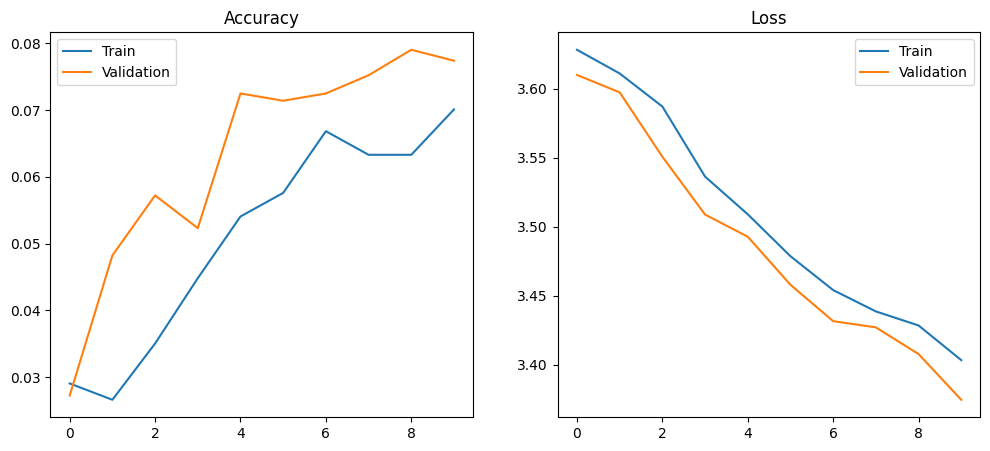

In [36]:
def plot_history(history):
    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Validation')
    plt.title("Accuracy")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Validation')
    plt.title("Loss")
    plt.legend()
    plt.show()

plot_history(history)


In [37]:
def build_model_hp(dense_units=[512,256], dropout_rate=0.5, input_shape=(224,224,3), num_classes=37):
    # ساخت AlexNet فریز شده
    base_model = build_alexnet(input_shape)
    for layer in base_model.layers:
        layer.trainable = False

    # اضافه کردن Dense layers
    model = models.Sequential()
    model.add(base_model)

    for units in dense_units:
        model.add(layers.Dense(units, activation='relu'))
        model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(num_classes, activation='softmax'))

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model


In [38]:
hyperparams = [
    {'dense_units':[512,256], 'dropout_rate':0.5, 'name':'2Dense_512-256_DR0.5'},
    {'dense_units':[256,128], 'dropout_rate':0.3, 'name':'2Dense_256-128_DR0.3'},
    {'dense_units':[512], 'dropout_rate':0.5, 'name':'1Dense_512_DR0.5'},
    {'dense_units':[256], 'dropout_rate':0.3, 'name':'1Dense_256_DR0.3'}
]


In [39]:
histories = {}

for params in hyperparams:
    print(f"Training model: {params['name']}")
    model_hp = build_model_hp(dense_units=params['dense_units'],
                              dropout_rate=params['dropout_rate'],
                              num_classes=num_classes)

    history = model_hp.fit(
        train_ds,
        epochs=10,
        validation_data=test_ds
    )

    histories[params['name']] = history


Training model: 2Dense_512-256_DR0.5
Epoch 1/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 25s 169ms/step - accuracy: 0.0204 - loss: 3.6594 - val_accuracy: 0.0283 - val_loss: 3.6101
Epoch 2/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 21s 162ms/step - accuracy: 0.0245 - loss: 3.6166 - val_accuracy: 0.0384 - val_loss: 3.6091
Epoch 3/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 20s 151ms/step - accuracy: 0.0367 - loss: 3.6062 - val_accuracy: 0.0379 - val_loss: 3.5930
Epoch 4/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 20s 154ms/step - accuracy: 0.0405 - loss: 3.5832 - val_accuracy: 0.0466 - val_loss: 3.5498
Epoch 5/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 20s 160ms/step - accuracy: 0.0380 - loss: 3.5609 - val_accuracy: 0.0450 - val_loss: 3.5177
Epoch 6/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 19s 146ms/step - accuracy: 0.0494 - loss: 3.5197 - val_accuracy: 0.0542 - val_loss: 3.5104
Epoch 7/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 21s 154ms/step - accuracy: 0.0428 - loss: 3.5331 - val_accuracy: 0.0518 - val_loss: 3.5009
Epoch 8/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 19s 14

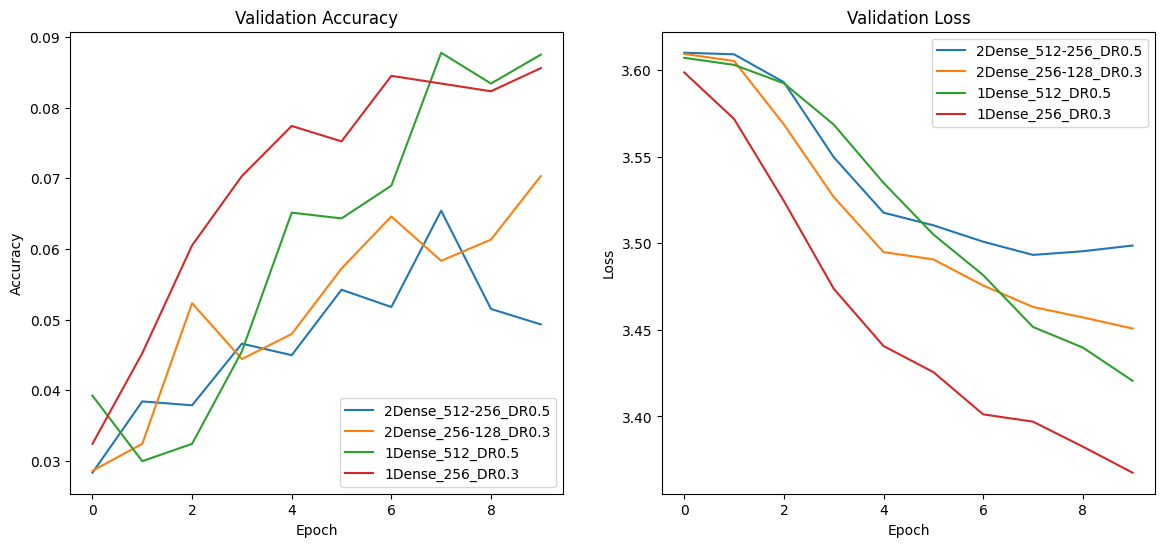

In [40]:
def plot_all_histories(histories):
    plt.figure(figsize=(14,6))

    # Accuracy
    plt.subplot(1,2,1)
    for name, history in histories.items():
        plt.plot(history.history['val_accuracy'], label=name)
    plt.title("Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    # Loss
    plt.subplot(1,2,2)
    for name, history in histories.items():
        plt.plot(history.history['val_loss'], label=name)
    plt.title("Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.show()

plot_all_histories(histories)
